In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme("talk", "ticks")

# Total MI varying kind of data

## MRI

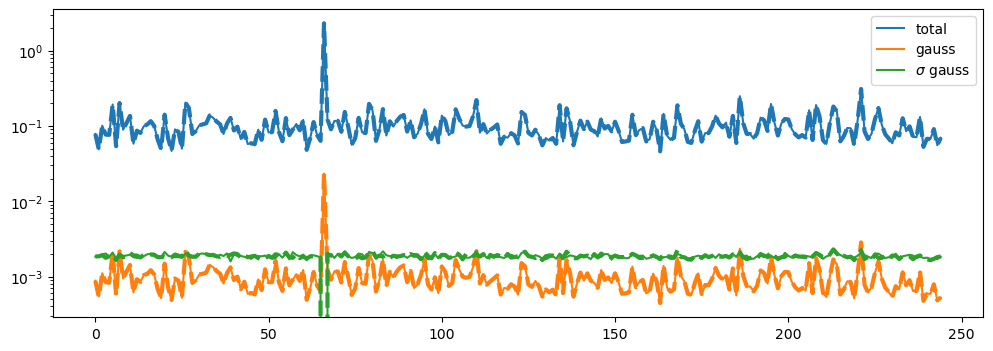

In [8]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

with open("/mnt/DATA/NonLinearMI/eso245_cra_strin_10var1_bin8/globalStats.json") as fp:
    chiappa = {k:np.array(v) for k, v in json.load(fp).items()}

order = np.argsort(1-chiappa["globalgaussMI"]/chiappa["globaltotalMI"])
buoni = {k:v[order] for k,v in chiappa.items()}

with open("/mnt/DATA/NonLinearMI/eso245_cra_strin_10var2_bin8/globalStats.json") as fp:
    secondi = {k:np.array(v)[order] for k, v in json.load(fp).items()}

fig = plt.figure(figsize=(12,4))
p,=plt.plot(buoni["globaltotalMI"], label="total")
plt.plot(secondi["globaltotalMI"], lw=3, ls="--", color=p.get_color())

p,=plt.plot(buoni["globalgaussMI"], label="gauss")
plt.plot(secondi["globalgaussMI"], lw=3, ls="--", color=p.get_color())

p,=plt.plot(buoni["globalsigmaGaussMI"], label=r"$\sigma$ gauss")
plt.plot(secondi["globalsigmaGaussMI"], lw=3, ls="--", color=p.get_color())
plt.yscale("log")
plt.legend()
# plt.twinx()
# plt.errorbar(np.arange(245), 1-buoni["globalgaussMI"]/buoni["globaltotalMI"], buoni["globalsigmaGaussMI"]/buoni["globaltotalMI"])
plt.show()

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

listheo=[]
listrue=[]
statsReg = {}
for folder in glob.glob("/mnt/DATA/NonLinearMI/eso245_cra_strin_*"):
    if os.path.isfile(os.path.join(folder,"globalStats.json")):
        statsMI = np.load(os.path.join(folder,f"patient00_9.npy"))
        pairs = statsMI.shape[0]
        regions = int(0.5+np.sqrt(0.25+2*pairs))
        theo = int(re.findall(r"_(\d+)", folder)[0])
        listheo.append(theo)
        listrue.append(regions)
        print(folder, theo, regions, statsMI.shape)
        with open(os.path.join(folder,"globalStats.json")) as fp:
            statsReg[regions] = {k:np.array(v) for k, v in json.load(fp).items()}
#del statsReg[586]
order = np.argsort(listheo)
plt.plot(np.array(listheo)[order], np.array(listrue)[order], "o--")
plt.plot(np.array(listheo)[order], np.array(listheo)[order], ":k", lw=0.5)
plt.xlabel("Designed number of regions")
plt.ylabel("Effective number of regions")
plt.show()


In [ ]:
x=sorted(statsReg.keys())
all=np.zeros((19, len(x)))
for pat in range(19):
    y = [2*(statsReg[i]["globaltotalMI"][pat]-statsReg[i]["globalgaussMI"][pat])/(statsReg[i]["globaltotalMI"][pat]+statsReg[i]["globalgaussMI"][pat]) if len(statsReg[i]["globaltotalMI"])>pat else np.NaN for i in x]
    plt.plot(x, y, "o--b", lw=1, alpha=0.5)#, label=pat)
    all[pat,:]=y
my=np.nanmean(all, axis=0)
sy=np.nanstd(all, axis=0)
plt.plot([x[0], x[-1]], [0,0], "-r", lw=1, label=0, zorder=1)
plt.fill_between(x, my-2*sy, my+2*sy, color="yellow", alpha=1, edgecolor=None, label=r"$\pm 2 \sigma$")
plt.fill_between(x, my-sy, my+sy, color="green", alpha=0.5, edgecolor=None, label=r"$\pm 1 \sigma$")
plt.plot(x, my, "--k", lw=2, label="mean")
plt.ylabel("relative difference in MI")
plt.xlabel("# of regions")
plt.xscale("log")
plt.title("First 19 subjects")
plt.legend()
plt.show()


In [ ]:
x=sorted(statsReg.keys())

all=np.zeros((19, len(x)))
y=[]
for i in x:
    y.append(((statsReg[i]["globaltotalMI"]-statsReg[i]["globalgaussMI"])/(statsReg[i]["globaltotalMI"]+statsReg[i]["globalgaussMI"])))
p1,= plt.plot([1, len(x)], [0,0], "-r", lw=1, label=0, zorder=1)
plt.boxplot(y, whis=2,boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos=np.arange(len(x))+1
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xlabel("# of regions")
plt.legend([Patch(facecolor="white", edgecolor="darkorange"), p1], ["Total MI vs Gauss MI", r"0"])
plt.title("All subjects")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,6))
bpx=[]
for i in x:
    tmp = statsReg[i]["globaltotalMI"]
    bpx.append([a for a in tmp if a != max(tmp)])
xpos = np.arange(1,46,2)+0.15
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})
bpx=[]
for i in x:
    tmp = statsReg[i]["globalgaussMI"]
    bpx.append([a for a in tmp if a != max(tmp)])
xpos = np.arange(2,47,2)-0.15
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos = np.arange(1,46,2)+0.5
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylim(bottom=0)
cont=0.15*np.power(x, -1/4)
p1,=plt.plot(tkpos, cont, ":k", lw=1)
p2,=plt.plot(tkpos, cont, "xr", lw=1)
plt.legend([Patch(facecolor="white", edgecolor="b"), Patch(facecolor="white", edgecolor="darkorange"), (p1,p2)], ["Total MI", "Gauss MI", r"$\propto x^{-1/4}$"])
plt.xlabel("# of regions")
plt.ylabel("MI")
plt.show()

## EEG BLP electrode

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

statsReg = {}
for folder in glob.glob("/mnt/DATA/NonLinearMI/electrode_BLP_band*"):
    if os.path.isfile(os.path.join(folder,"globalStats.json")):
        statsMI = np.load(os.path.join(folder,f"patient00_8.npy"))
        pairs = statsMI.shape[0]
        band = int(re.findall(r"band(\d+)", folder)[0])
        print(folder, band, statsMI.shape)
        with open(os.path.join(folder,"globalStats.json")) as fp:
            statsReg[band] = {k:np.array(v) for k, v in json.load(fp).items()}


In [ ]:
x=sorted(statsReg.keys())

all=np.zeros((19, len(x)))
for pat in range(19):
    y = [2*(statsReg[i]["globaltotalMI"][pat]-statsReg[i]["globalgaussMI"][pat])/(statsReg[i]["globaltotalMI"][pat]+statsReg[i]["globalgaussMI"][pat]) if len(statsReg[i]["globaltotalMI"])>pat else np.NaN for i in x]
    plt.plot(x, y, "o--b", lw=1, alpha=0.5)
    all[pat,:]=y
my=np.nanmean(all, axis=0)
sy=np.nanstd(all, axis=0)
plt.plot([x[0], x[-1]], [0,0], "-r", lw=1, label=0, zorder=1)
plt.fill_between(x, my-2*sy, my+2*sy, color="yellow", alpha=1, edgecolor=None, label=r"$\pm 2 \sigma$")
plt.fill_between(x, my-sy, my+sy, color="green", alpha=0.5, edgecolor=None, label=r"$\pm 1 \sigma$")
plt.plot(x, my, "--k", lw=2, label="mean")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.ylabel("relative difference in MI")
plt.xlabel("Band")
plt.legend()
plt.title("First 19 subjects")
plt.show()


In [ ]:
x=sorted(statsReg.keys())

y=[]
for i in x:
    y.append(((statsReg[i]["globaltotalMI"]-statsReg[i]["globalgaussMI"])/(statsReg[i]["globaltotalMI"]+statsReg[i]["globalgaussMI"])))
p1,= plt.plot([1, len(x)], [0,0], "-r", lw=1, label=0, zorder=1)
plt.boxplot(y, whis=2,boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos=np.arange(len(x))+1
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xlabel("Band")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.legend([Patch(facecolor="white", edgecolor="darkorange"), p1], ["Total MI vs Gauss MI", r"0"])
plt.title("All subjects")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,6))
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globaltotalMI"])
xpos = 2*np.array(x)-0.8
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globalgaussMI"])
xpos = 2*np.array(x)-0.2
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos = 2*np.array(x)-0.5
plt.xticks(tkpos, labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"], rotation=45, fontsize="small")
plt.ylim(bottom=0)
plt.legend([Patch(facecolor="white", edgecolor="b"), Patch(facecolor="white", edgecolor="darkorange")], ["Total MI", "Gauss MI"])
plt.xlabel("Band")
plt.ylabel("MI")
plt.show()

## EEG BLP source

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

statsReg = {}
for folder in glob.glob("/mnt/DATA/NonLinearMI/source_BLP_band*"):
    if os.path.isfile(os.path.join(folder,"globalStats.json")):
        try:
            statsMI = np.load(os.path.join(folder,f"patient00_8.npy"))
        except:
            statsMI = np.ndarray((0,))
        band = int(re.findall(r"band(\d+)", folder)[0])
        print(folder, band, statsMI.shape)
        with open(os.path.join(folder,"globalStats.json")) as fp:
            statsReg[band] = {k:np.array(v) for k, v in json.load(fp).items()}


In [ ]:
x=sorted(statsReg.keys())

all=np.zeros((19, len(x)))
for pat in range(19):
    y = [2*(statsReg[i]["globaltotalMI"][pat]-statsReg[i]["globalgaussMI"][pat])/(statsReg[i]["globaltotalMI"][pat]+statsReg[i]["globalgaussMI"][pat]) if len(statsReg[i]["globaltotalMI"])>pat else np.NaN for i in x]
    plt.plot(x, y, "o--b", lw=1, alpha=0.5)
    all[pat,:]=y
my=np.nanmean(all, axis=0)
sy=np.nanstd(all, axis=0)
plt.plot([x[0], x[-1]], [0,0], "-r", lw=1, label=0, zorder=1)
plt.fill_between(x, my-2*sy, my+2*sy, color="yellow", alpha=1, edgecolor=None, label=r"$\pm 2 \sigma$")
plt.fill_between(x, my-sy, my+sy, color="green", alpha=0.5, edgecolor=None, label=r"$\pm 1 \sigma$")
plt.plot(x, my, "--k", lw=2, label="mean")
plt.ylabel("relative difference in MI")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.xlabel("Band")
plt.legend()
plt.title("First 19 subjects")
plt.show()


In [ ]:
x=sorted(statsReg.keys())

y=[]
for i in x:
    y.append(((statsReg[i]["globaltotalMI"]-statsReg[i]["globalgaussMI"])/(statsReg[i]["globaltotalMI"]+statsReg[i]["globalgaussMI"])))
p1,= plt.plot([1, len(x)], [0,0], "-r", lw=1, label=0, zorder=1)
plt.boxplot(y, whis=2,boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos=np.arange(len(x))+1
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.xlabel("Band")
plt.legend([Patch(facecolor="white", edgecolor="darkorange"), p1], ["Total MI vs Gauss MI", r"0"])
plt.title("All subjects")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,6))
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globaltotalMI"])
xpos = 2*np.array(x)-0.8
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globalgaussMI"])
xpos = 2*np.array(x)-0.2
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos = 2*np.arange(1,10)-0.5
# tkpos = 2*np.array(x)-0.5
plt.xticks(tkpos, labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"], rotation=45, fontsize="small")
plt.ylim(bottom=0)
plt.legend([Patch(facecolor="white", edgecolor="b"), Patch(facecolor="white", edgecolor="darkorange")], ["Total MI", "Gauss MI"])
plt.xlabel("Band")
plt.ylabel("MI")
plt.show()

## Raw electrode

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

statsReg = {}
for folder in glob.glob("/mnt/DATA/NonLinearMI/EEG_bands_band?_bin50"):
    if os.path.isfile(os.path.join(folder,"globalStats.json")):
        try:
            statsMI = np.load(os.path.join(folder,f"patient00_50.npy"))
        except:
            statsMI=np.array([])
        pairs = statsMI.shape[0]
        band = int(re.findall(r"band(\d+)", folder)[0])
        print(folder, band, statsMI.shape)
        with open(os.path.join(folder,"globalStats.json")) as fp:
            statsReg[band] = {k:np.array(v) for k, v in json.load(fp).items()}


In [ ]:
x=sorted(statsReg.keys())

all=np.zeros((19, len(x)))
for pat in range(19):
    y = [2*(statsReg[i]["globaltotalMI"][pat]-statsReg[i]["globalgaussMI"][pat])/(statsReg[i]["globaltotalMI"][pat]+statsReg[i]["globalgaussMI"][pat]) if len(statsReg[i]["globaltotalMI"])>pat else np.NaN for i in x]
    plt.plot(x, y, "o--b", lw=1, alpha=0.5)
    all[pat,:]=y
my=np.nanmean(all, axis=0)
sy=np.nanstd(all, axis=0)
plt.plot([x[0], x[-1]], [0,0], "-r", lw=1, label=0, zorder=1)
plt.fill_between(x, my-2*sy, my+2*sy, color="yellow", alpha=1, edgecolor=None, label=r"$\pm 2 \sigma$")
plt.fill_between(x, my-sy, my+sy, color="green", alpha=0.5, edgecolor=None, label=r"$\pm 1 \sigma$")
plt.plot(x, my, "--k", lw=2, label="mean")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.ylabel("relative difference in MI")
plt.xlabel("Band")
plt.legend()
plt.title("First 19 subjects")
plt.show()


In [ ]:
x=sorted(statsReg.keys())

y=[]
for i in x:
    y.append(((statsReg[i]["globaltotalMI"]-statsReg[i]["globalgaussMI"])/(statsReg[i]["globaltotalMI"]+statsReg[i]["globalgaussMI"])))
p1,= plt.plot([1, len(x)], [0,0], "-r", lw=1, label=0, zorder=1)
plt.boxplot(y, whis=2,boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos=np.arange(len(x))+1
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xlabel("Band")
plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.legend([Patch(facecolor="white", edgecolor="darkorange"), p1], ["Total MI vs Gauss MI", r"0"])
plt.title("All subjects")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,6))
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globaltotalMI"])
xpos = 2*np.array(x)-0.8
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globalgaussMI"])
xpos = 2*np.array(x)-0.2
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos = 2*np.arange(1,10)-0.5
plt.xticks(tkpos, labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"], rotation=45, fontsize="small")
plt.ylim(bottom=0)
plt.legend([Patch(facecolor="white", edgecolor="b"), Patch(facecolor="white", edgecolor="darkorange")], ["Total MI", "Gauss MI"])
plt.xlabel("Band")
plt.ylabel("MI")
plt.show()

## iEEG

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

statsReg = {}
folder = "/mnt/DATA/NonLinearMI/iEEG_part_bin18"
if os.path.isfile(os.path.join(folder,"globalStats.json")):
    try:
        statsMI = np.load(os.path.join(folder,f"patient00_18.npy"))
    except:
        statsMI=np.array([])
    pairs = statsMI.shape[0]
    band = "all"
    print(folder, band, statsMI.shape)
    with open(os.path.join(folder,"globalStats.json")) as fp:
        statsReg[band] = {k:np.array(v) for k, v in json.load(fp).items()}


In [ ]:
x=sorted(statsReg.keys())

all=np.zeros((18, len(x)))
for pat in range(18):
    y = [2*(statsReg[i]["globaltotalMI"][pat]-statsReg[i]["globalgaussMI"][pat])/(statsReg[i]["globaltotalMI"][pat]+statsReg[i]["globalgaussMI"][pat]) if len(statsReg[i]["globaltotalMI"])>pat else np.NaN for i in x]
    plt.plot(x, y, "o--b", lw=1, alpha=0.5)
    all[pat,:]=y
x=[0]
my=np.nanmean(all, axis=0)
sy=np.nanstd(all, axis=0)
plt.plot([x[0]-0.2, x[0]+0.2], [0,0], "-r", lw=1, label=0, zorder=1)
plt.fill_between([x[0]-0.2, x[0]+0.2], [(my-2*sy)[0]]*2, [(my+2*sy)[0]]*2, color="yellow", alpha=1, edgecolor=None, label=r"$\pm 2 \sigma$")
plt.fill_between([x[0]-0.2, x[0]+0.2], [(my-sy)[0]]*2, [(my+sy)[0]]*2, color="green", alpha=0.5, edgecolor=None, label=r"$\pm 1 \sigma$")
plt.plot([x[0]-0.2, x[0]+0.2], [my]*2, "--k", lw=2, label="mean")
#plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.ylabel("relative difference in MI")
plt.xlabel("iEEG")
plt.legend()
plt.title("All 18 subjects")
plt.show()


In [ ]:
x=sorted(statsReg.keys())

y=[]
for i in x:
    y.append(((statsReg[i]["globaltotalMI"]-statsReg[i]["globalgaussMI"])/(statsReg[i]["globaltotalMI"]+statsReg[i]["globalgaussMI"])))
p1,= plt.plot([0.8, len(x)+0.2], [0,0], "-r", lw=1, label=0, zorder=1)
plt.boxplot(y, whis=2,boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos=np.arange(len(x))+1
plt.xticks(tkpos, x, rotation=45, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xlabel("iEEG")
#plt.xticks(ticks=np.arange(1,10), labels=[r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta_{LOW}$",r"$\beta_{MID}$",r"$\beta_{HIGH}$",r"$\gamma$",r"$\beta_{ALL}$",r"$1-40 Hz$"])
plt.legend([Patch(facecolor="white", edgecolor="darkorange"), p1], ["Total MI \nvs Gauss MI", r"0"])
plt.title("All subjects")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,6))
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globaltotalMI"])
xpos = [0.8]#2*np.array(x)-0.8
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})
bpx=[]
for i in x:
    bpx.append(statsReg[i]["globalgaussMI"])
xpos = [1.2]#2*np.array(x)-0.2
plt.boxplot(bpx, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})
tkpos = [1]#2*np.arange(1,10)-0.5
plt.xticks(tkpos, labels=[r"all"])
plt.ylim(bottom=0)
plt.legend([Patch(facecolor="white", edgecolor="b"), Patch(facecolor="white", edgecolor="darkorange")], ["Total MI", "Gauss MI"])
plt.xlabel("iEEG")
plt.ylabel("MI")
plt.show()

# Number of bins and number of samples effect

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from matplotlib.patches import Patch

samples = {"many":{},"sub":{}}
nctr = {"many":{},"sub":{}}
for folder in glob.glob("/mnt/DATA/NonLinearMI/EEG_bands_band1_*"):
    if os.path.isfile(os.path.join(folder,"globalStats.json")):
        try:
            statfil = glob.glob(os.path.join(folder,f"patient00_*.npy"))
            statsMI = np.load(statfil[0])
        except:
            statsMI=np.array([])
        pairs = statsMI.shape[0]
        bins = int(re.findall(r"bin(\d+)", folder)[0])
        cat = "sub" if re.findall(r"sub", folder) else "many"
        print(folder, bins, statsMI.shape)
        with open(os.path.join(folder,"globalStats.json")) as fp:
            samples[cat][bins] = {k:np.array(v) for k, v in json.load(fp).items()}
        newco = np.load(os.path.join(folder, f"newco_{bins}.npy"))
        trueval = np.load(os.path.join(folder, f"trueval_{bins}.npy"))
        nctr[cat][bins]=np.stack([newco, trueval], -1)

In [ ]:
x = [8,16,50]
p1,= plt.plot([-1, 2*len(x)-2], [0,0], "--r", lw=1, label=0, zorder=1)


y=[]
for i in x:
    if i in samples["many"]:
        y.append(((samples["many"][i]["globaltotalMI"]-samples["many"][i]["globalgaussMI"])/(samples["many"][i]["globaltotalMI"]+samples["many"][i]["globalgaussMI"]))[:41])
    else:
        y.append([])
xpos = 2*np.arange(len(x))-0.8
plt.boxplot(y, whis=2, positions=xpos, boxprops={"color":"darkorange"}, whiskerprops={"color":"darkorange"}, flierprops={"color":"darkorange"}, medianprops={"lw":1.6,"color":"darkorange"}, capprops={"color":"darkorange"})


y=[]
for i in x:
    if i in samples["sub"]:
        y.append(((samples["sub"][i]["globaltotalMI"]-samples["sub"][i]["globalgaussMI"])/(samples["sub"][i]["globaltotalMI"]+samples["sub"][i]["globalgaussMI"]))[:41])
    else:
        y.append([])
xpos = 2*np.arange(len(x))-0.2
plt.boxplot(y, whis=2, positions=xpos, boxprops={"color":"b"}, whiskerprops={"color":"b"}, flierprops={"color":"b"}, medianprops={"lw":1.6,"color":"b"}, capprops={"color":"b"})


tkpos=2*np.arange(len(x))-0.5
plt.xticks(tkpos, x, rotation=0, fontsize="small")
plt.ylabel("relative difference in MI")
plt.xlabel("# of bins")
plt.legend([Patch(facecolor="white", edgecolor="darkorange"),Patch(facecolor="white", edgecolor="b")], ["100 Hz", "10 Hz"], title="Sampling", loc=2)
plt.title("All subjects")
plt.show()

In [ ]:
from matplotlib.lines import Line2D
plt.figure(figsize=(10,8))
styles={8:":",16:"--",50:"-"}
colors={"many":"darkorange","sub":"b"}
names={"many":"100 Hz","sub":"10 Hz"}
for k in nctr:
    for k2 in nctr[k]:
        newco, trueval = nctr[k][k2].T
        plt.plot(trueval,newco,linestyle=styles[k2], color=colors[k])


plt.plot([min(trueval), max(trueval)], [min(trueval), max(trueval)], ":k")
handles=[Patch(facecolor="white", edgecolor="white")]
labels=["Sampling"]
for k in colors:
    handles.append(Line2D([],[],linewidth=1.5, color=colors[k]))
    labels.append(names[k])
handles.append(Patch(facecolor="white", edgecolor="white"))
labels.append("Bins")
for k in styles:
    handles.append(Line2D([],[],linewidth=1.5, linestyle=styles[k], color="k"))
    labels.append(str(k))
plt.legend(handles, labels)
plt.xlim(left=0)
plt.show()